### Import Library

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

### Membaca Dataset

In [118]:
file_path = '/content/drive/MyDrive/Fesmaro/Dataset Kedua.csv'
df = pd.read_csv(file_path, encoding='latin1', sep= ';')
df.head()

/tmp/ipykernel_4346/3015541986.py:2: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='latin1', sep= ';')


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,3.146.400.146,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,02/03/2018 22:56,Standard Class
1,TRANSFER,5,4,-2.490.899.963,3.113.599.854,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-2.477.799.988,3.097.200.012,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,2.286.000.061,3.048.099.976,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,1.342.100.067,298.25,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


### Data Preparation

In [119]:
# --- MEMBERSIHKAN TEKS ANGKA ---
def bersihkan_angka(teks):
    teks = str(teks).strip().replace('$', '').replace(',', '')
    if teks.count('.') > 1:
        teks = teks.replace('.', '')
    return teks

In [120]:
# --- MEMBERSIHKAN & KONVERSI 4 KOLOM DASAR ---
kolom_dasar = ['Order Item Product Price', 'Order Item Quantity',
               'Order Item Discount Rate', 'Order Item Profit Ratio']

for col in kolom_dasar:
    if df[col].dtype == 'object':
        df[col] = df[col].apply(bersihkan_angka)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [121]:
# --- REKONSTRUKSI MATEMATIS KOLOM TURUNAN ---
df['Order Item Discount'] = df['Order Item Product Price'] * df['Order Item Quantity'] * df['Order Item Discount Rate']
df['Order Item Total'] = (df['Order Item Product Price'] * df['Order Item Quantity']) - df['Order Item Discount']

df['Sales'] = df['Order Item Total']
df['Sales per customer'] = df['Order Item Total']
df['Product Price'] = df['Order Item Product Price']

df['Benefit per order'] = df['Order Item Total'] * df['Order Item Profit Ratio']
df['Order Profit Per Order'] = df['Benefit per order']

In [122]:
# --- MELAKUKAN FORMAT PADA KOLOM TANGGAL ---
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], format='mixed', errors='coerce')
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'], format='mixed', errors='coerce')

In [123]:
# --- MENANGANI MISSING VALUES & DROP KOLOM ---
kolom_dihapus = ['Customer Password', 'Product Description', 'Product Image']
df = df.drop(columns=[col for col in kolom_dihapus if col in df.columns])

if 'Order Zipcode' in df.columns:
    df['Order Zipcode'] = df['Order Zipcode'].fillna(-1)
if 'Customer Zipcode' in df.columns:
    df['Customer Zipcode'] = df['Customer Zipcode'].fillna(-1)

if 'Customer Lname' in df.columns:
    df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')

In [124]:
# --- MENAMPILKAN JUMLAH MISSING VALUE ---
print("Jumlah Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Jumlah Missing Values:
Series([], dtype: int64)


In [125]:
# --- NORMALISASI TEXT PADA KOLOM ---
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

In [126]:
# --- MENGHAPUS ANOMALI MENGGUNAKAN METODE IQR ---
df_daily = df.groupby(df['order_date_(dateorders)'].dt.date)['order_item_quantity'].sum().reset_index()
df_daily.columns = ['ds', 'y']
df_daily['ds'] = pd.to_datetime(df_daily['ds'])

Q1 = df_daily['y'].quantile(0.25)
Q3 = df_daily['y'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomali = df_daily[(df_daily['y'] < lower_bound) | (df_daily['y'] > upper_bound)]
print(f"Ditemukan {len(anomali)} titik anomali.")
print(anomali)

df_daily_clean = df_daily[(df_daily['y'] >= lower_bound) & (df_daily['y'] <= upper_bound)]

print(f"Data sebelum dibersihkan: {len(df_daily)} baris")
print(f"Data setelah dibersihkan: {len(df_daily_clean)} baris")

Ditemukan 124 titik anomali.
             ds    y
11   2015-01-12  493
194  2015-07-14  509
1005 2017-10-02  171
1006 2017-10-03   68
1007 2017-10-04   69
...         ...  ...
1122 2018-01-27   68
1123 2018-01-28   69
1124 2018-01-29   68
1125 2018-01-30   69
1126 2018-01-31   68

[124 rows x 2 columns]
Data sebelum dibersihkan: 1127 baris
Data setelah dibersihkan: 1003 baris


In [88]:
# --- MENAMPILKAN DATA SETELAH DATA PREPARATION ---
df.head(10)

,type,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_state,order_status,order_zipcode,product_card_id,product_category_id,product_name,product_price,product_status,shipping_date_(dateorders),shipping_mode
0,DEBIT,3,4,91.245598,314.640000,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,-1.0,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.090003,311.362500,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,-1.0,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-246.468004,308.085000,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,-1.0,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,24.384599,304.807500,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,-1.0,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.213621,298.252499,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,-1.0,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class
5,TRANSFER,6,4,17.698500,294.975000,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,Queensland,CANCELED,-1.0,1360,73,Smart watch,327.75,0,2018-01-19 11:03:00,Standard Class
6,DEBIT,2,1,95.178604,288.420001,Late delivery,1,73,Sporting Goods,Caguas,...,Guangdong,COMPLETE,-1.0,1360,73,Smart watch,327.75,0,2018-01-15 10:42:00,First Class
7,TRANSFER,2,1,68.434199,285.142502,Late delivery,1,73,Sporting Goods,Miami,...,Guangdong,PROCESSING,-1.0,1360,73,Smart watch,327.75,0,2018-01-15 10:21:00,First Class
8,CASH,3,2,133.721996,278.587498,Late delivery,1,73,Sporting Goods,Caguas,...,Guangdong,CLOSED,-1.0,1360,73,Smart watch,327.75,0,2018-01-16 10:00:00,Second Class
9,CASH,2,1,132.148798,275.310001,Late delivery,1,73,Sporting Goods,San Ramon,...,Guangdong,CLOSED,-1.0,1360,73,Smart watch,327.75,0,2018-01-15 09:39:00,First Class


### Exploratory Data Analysis (EDA)

In [56]:
df.describe().round(2)

,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,sales_per_customer,late_delivery_risk,category_id,customer_id,customer_zipcode,department_id,order_customer_id,...,order_item_quantity,sales,order_item_total,order_profit_per_order,order_zipcode,product_card_id,product_category_id,product_price,product_status,shipping_date_(dateorders)
count,180519.00,180519.00,1.805190e+05,1.805190e+05,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,...,180519.00,1.805190e+05,1.805190e+05,1.805190e+05,180519.00,180519.00,180519.00,1.805190e+05,180519.0,180519
mean,3.50,2.93,-3.270641e+17,7.207497e+09,0.55,31.85,6691.38,35920.53,5.44,6691.38,...,2.13,7.207497e+09,7.207497e+09,-3.270641e+17,7625.95,692.51,31.85,3.021983e+09,0.0,2016-06-16 05:45:23.202433024
min,0.00,0.00,-1.336366e+20,1.650000e+01,0.00,2.00,1.00,-1.00,2.00,1.00,...,1.00,1.650000e+01,1.650000e+01,-1.336366e+20,-1.00,19.00,2.00,2.200000e+01,0.0,2015-01-03 00:00:00
25%,2.00,2.00,3.150000e+01,3.479826e+08,0.00,18.00,3258.50,725.00,4.00,3258.50,...,1.00,3.479826e+08,3.479826e+08,3.150000e+01,-1.00,403.00,18.00,3.999800e+08,0.0,2015-09-25 06:59:00
50%,3.00,4.00,2.339820e+08,1.819909e+09,1.00,29.00,6457.00,19380.00,5.00,6457.00,...,1.00,1.819909e+09,1.819909e+09,2.339820e+08,-1.00,627.00,29.00,1.999900e+09,0.0,2016-06-15 08:32:00
75%,5.00,4.00,1.899240e+09,1.151808e+10,1.00,45.00,9779.00,78207.00,7.00,9779.00,...,3.00,1.151808e+10,1.151808e+10,1.899240e+09,-1.00,1004.00,45.00,4.998000e+09,0.0,2017-03-04 21:29:00
max,6.00,4.00,2.499750e+10,4.999500e+10,1.00,76.00,20757.00,99205.00,12.00,20757.00,...,5.00,4.999500e+10,4.999500e+10,2.499750e+10,99301.00,1363.00,76.00,9.999900e+09,0.0,2018-02-06 22:14:00
std,1.62,1.37,3.573156e+18,9.802152e+09,0.50,15.64,4162.92,37542.43,1.63,4162.92,...,1.45,9.802152e+09,9.802152e+09,3.573156e+18,22466.92,336.45,15.64,2.901719e+09,0.0,NaN


### Visualisasi Data

/tmp/ipykernel_4346/3862268408.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily_clean['month'] = df_daily_clean['ds'].dt.to_period('M')


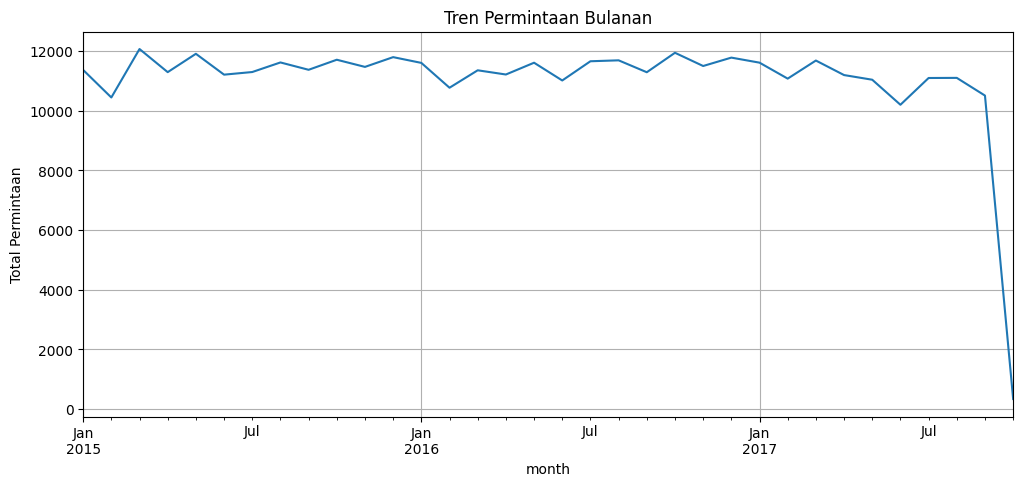

In [74]:
# --- MENAMPILKAN GRAFIK TREN PERMINTAAN BULANAN ---
df_daily_clean['month'] = df_daily_clean['ds'].dt.to_period('M')
monthly = df_daily_clean.groupby('month')['y'].sum()

plt.figure(figsize=(12,5))
monthly.plot()
plt.title('Tren Permintaan Bulanan')
plt.ylabel('Total Permintaan')
plt.grid(True)
plt.show()

/tmp/ipykernel_4346/4048591254.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')


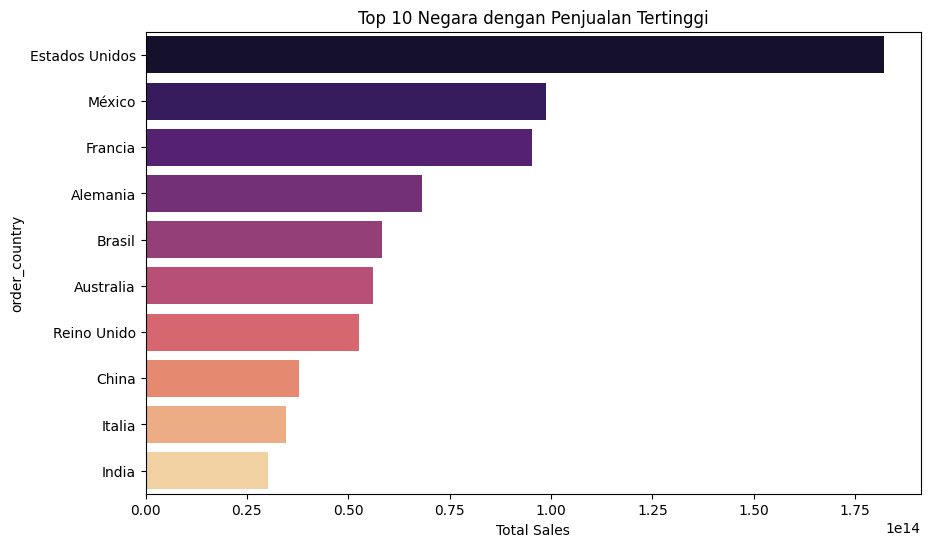

In [75]:
# --- MENAMPILKAN GRAFIK NEGARA DENGAN PENJUALAN TERTINGGI BERDASARKAN ANALISIS GEOGRAFI ---
plt.figure(figsize=(10, 6))
top_countries = df.groupby('order_country')['sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title('Top 10 Negara dengan Penjualan Tertinggi')
plt.xlabel('Total Sales')
plt.show()

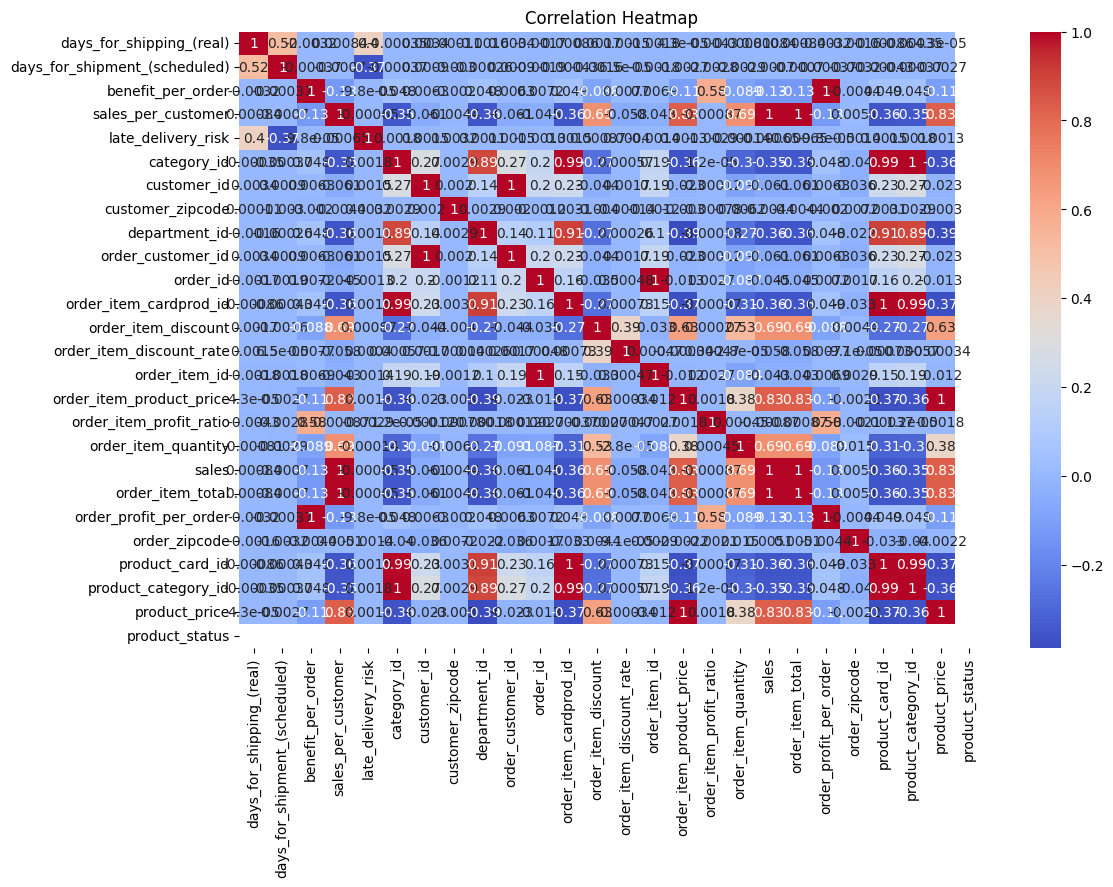

In [40]:
# --- MENAMPILKAN CORRELATION HEATMAP ---
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Model Preparation

In [139]:
# --- FEATURE ENGINEERING ---
df_featured = df_daily_clean.copy()

# Lag
for i in [1, 7, 30]:
    df_featured[f'lag_{i}'] = df_featured['y'].shift(i)

# Rolling shift
df_featured['rolling_mean_7'] = df_featured['y'].shift(1).rolling(7).mean()
df_featured['rolling_mean_30'] = df_featured['y'].shift(1).rolling(30).mean()

# Volatility
df_featured['rolling_std_7'] = df_featured['y'].shift(1).rolling(7).std()
df_featured['rolling_std_30'] = df_featured['y'].shift(1).rolling(30).std()

# Momentum
df_featured['diff_1'] = df_featured['y'].diff(1)
df_featured['diff_7'] = df_featured['y'].diff(7)

# Spike flag
threshold = df_featured['diff_1'].std()
df_featured['spike_flag'] = (df_featured['diff_1'].abs() > threshold).astype(int)

# Kalender
df_featured['day_of_week'] = df_featured['ds'].dt.dayofweek
df_featured['is_weekend'] = (df_featured['day_of_week'] >= 5).astype(int)
df_featured['month'] = df_featured['ds'].dt.month

df_featured = df_featured.dropna().reset_index(drop=True)

In [140]:
# --- SPLIT DATA ---
test_days = 31
train = df_featured.iloc[:-test_days]
test = df_featured.iloc[-test_days:]

features = [
    'lag_1', 'lag_7', 'lag_30',
    'rolling_mean_7', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_30',
    'diff_1', 'diff_7',
    'spike_flag',
    'day_of_week', 'is_weekend', 'month'
]

X_train = train[features]
y_train = train['y']
X_test = test[features]
y_test = test['y']

In [141]:
# --- MEMPERSIAPKAN MODEL ---
model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.5,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.5, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [142]:
# --- PREDIKSI ---
y_pred = model.predict(X_test)

In [143]:
# --- VOLATILITY ADJUSTMENT ---
volatility = X_test['rolling_std_7'].fillna(0).values

noise = np.random.normal(0, volatility * 0.15)

y_pred_adjusted = y_pred + noise

In [144]:
# --- CLIPPING ---
lower_bound = y_train.mean() - 3 * y_train.std()
upper_bound = y_train.mean() + 3 * y_train.std()

y_pred_adjusted = np.clip(y_pred_adjusted, lower_bound, upper_bound)

In [145]:
# --- EVALUASI HASIL MODEL ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred_adjusted))
mae = mean_absolute_error(y_test, y_pred_adjusted)
mape = np.mean(np.abs((y_test - y_pred_adjusted) / y_test)) * 100

print("=== FINAL MODEL ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

=== FINAL MODEL ===
RMSE : 6.7078
MAE  : 5.1569
MAPE : 1.51%


In [146]:
# --- HASIL PREDIKSI MODEL ---
results_df = pd.DataFrame({
    'Tanggal': test['ds'].dt.date,
    'Aktual': y_test.values,
    'Prediksi': np.round(y_pred_adjusted, 2),
    'Error': np.round(y_test.values - y_pred_adjusted, 2)
}).reset_index(drop=True)

print("-" * 65)
print(results_df.head(15))
print("-" * 65)

-----------------------------------------------------------------
       Tanggal  Aktual  Prediksi  Error
0   2017-09-01     408    400.92   7.08
1   2017-09-02     375    376.28  -1.28
2   2017-09-03     391    393.78  -2.78
3   2017-09-04     336    330.17   5.83
4   2017-09-05     372    366.86   5.14
5   2017-09-06     345    340.97   4.03
6   2017-09-07     301    300.88   0.12
7   2017-09-08     364    375.15 -11.15
8   2017-09-09     365    364.49   0.51
9   2017-09-10     386    379.18   6.82
10  2017-09-11     387    382.95   4.05
11  2017-09-12     358    360.30  -2.30
12  2017-09-13     336    342.38  -6.38
13  2017-09-14     327    344.04 -17.04
14  2017-09-15     322    326.16  -4.16
-----------------------------------------------------------------


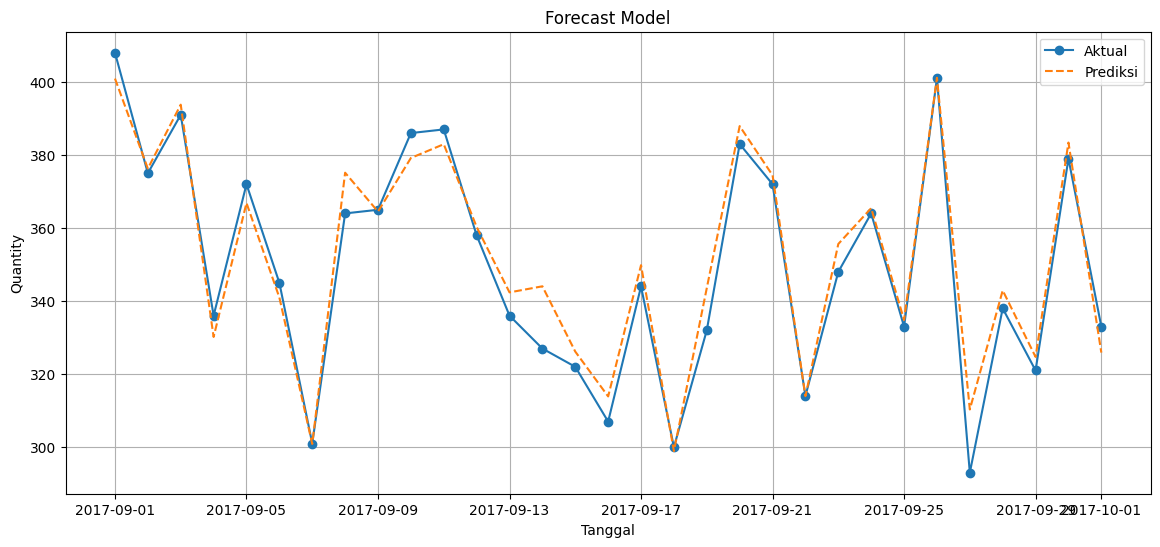

In [147]:
# --- VISUALISASI HASIL ---
plt.figure(figsize=(14,6))

plt.plot(test['ds'], y_test, label='Aktual', marker='o')
plt.plot(test['ds'], y_pred_adjusted, label='Prediksi', linestyle='--')

plt.title('Forecast Model')
plt.xlabel('Tanggal')
plt.ylabel('Quantity')
plt.legend()
plt.grid(True)
plt.show()

### Validasi Model dengan Walk-Forward Validation

In [148]:
# --- MEMPERSIAPKAN WALK-FORWARD VALIDATION ---
window_size = 30
start_index = int(len(df_featured) * 0.7)

rmse_list, mae_list, mape_list = [], [], []

print("=== WALK-FORWARD VALIDATION ===\n")

for start in range(start_index, len(df_featured) - window_size, window_size):

    train = df_featured.iloc[:start]
    test = df_featured.iloc[start:start + window_size]

    X_train = train[features]
    y_train = train['y']
    X_test = test[features]
    y_test = test['y']

    # Model
    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        gamma=0.5,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Volatility adjustment
    volatility = X_test['rolling_std_7'].fillna(0).values
    noise = np.random.normal(0, volatility * 0.15)
    y_pred = y_pred + noise

    # Clipping
    lower_bound = y_train.mean() - 3 * y_train.std()
    upper_bound = y_train.mean() + 3 * y_train.std()
    y_pred = np.clip(y_pred, lower_bound, upper_bound)

    # Metriks
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    rmse_list.append(rmse)
    mae_list.append(mae)
    mape_list.append(mape)

    print(f"Window mulai index {start}:")
    print(f"RMSE = {rmse:.3f} | MAE = {mae:.3f} | MAPE = {mape:.2f}%\n")

=== WALK-FORWARD VALIDATION ===

Window mulai index 681:
RMSE = 5.521 | MAE = 3.932 | MAPE = 1.05%

Window mulai index 711:
RMSE = 7.110 | MAE = 4.710 | MAPE = 1.19%

Window mulai index 741:
RMSE = 8.239 | MAE = 5.505 | MAPE = 1.48%

Window mulai index 771:
RMSE = 7.056 | MAE = 5.723 | MAPE = 1.56%

Window mulai index 801:
RMSE = 7.306 | MAE = 5.558 | MAPE = 1.57%

Window mulai index 831:
RMSE = 15.160 | MAE = 10.295 | MAPE = 3.19%

Window mulai index 861:
RMSE = 13.226 | MAE = 10.334 | MAPE = 3.11%

Window mulai index 891:
RMSE = 6.729 | MAE = 5.604 | MAPE = 1.60%

Window mulai index 921:
RMSE = 5.816 | MAE = 4.516 | MAPE = 1.25%



In [149]:
# --- RATA-RATA HASIL WALK-FORWARD VALIDATION ---
print("=== RATA-RATA PERFORMA MODEL ===")
print(f"RMSE Mean : {np.mean(rmse_list):.3f}")
print(f"MAE Mean  : {np.mean(mae_list):.3f}")
print(f"MAPE Mean : {np.mean(mape_list):.2f}%")

=== RATA-RATA PERFORMA MODEL ===
RMSE Mean : 8.463
MAE Mean  : 6.242
MAPE Mean : 1.78%


### Implementasi Model pada Prediksi Real

In [150]:
# --- FEATURE ENGINEERING ---
df_model = df_daily_clean.copy()

for i in [1, 7, 30]:
    df_model[f'lag_{i}'] = df_model['y'].shift(i)

df_model['rolling_7'] = df_model['y'].shift(1).rolling(7).mean()
df_model['rolling_30'] = df_model['y'].shift(1).rolling(30).mean()

df_model['day_of_week'] = df_model['ds'].dt.dayofweek
df_model['is_weekend'] = (df_model['day_of_week'] >= 5).astype(int)

df_model = df_model.dropna()

features = [
    'lag_1','lag_7','lag_30',
    'rolling_7','rolling_30',
    'day_of_week','is_weekend'
]

In [151]:
# --- TRAIN MODEL ---
X = df_model[features]
y = df_model['y']

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [152]:
# --- MELAKUKAN FORCASTING ---
future_days = 30
last_data = df_model.copy()

future_preds = []
future_dates = []

for i in range(future_days):

    last_row = last_data.iloc[-1].copy()

    next_date = last_row['ds'] + pd.Timedelta(days=1)

    new_row = {}
    new_row['ds'] = next_date

    new_row['lag_1'] = last_data.iloc[-1]['y']
    new_row['lag_7'] = last_data.iloc[-7]['y']
    new_row['lag_30'] = last_data.iloc[-30]['y']

    new_row['rolling_7'] = last_data['y'].tail(7).mean()
    new_row['rolling_30'] = last_data['y'].tail(30).mean()

    new_row['day_of_week'] = next_date.dayofweek
    new_row['is_weekend'] = 1 if next_date.dayofweek >= 5 else 0

    X_new = pd.DataFrame([new_row])[features]

    y_pred = model.predict(X_new)[0]

    new_row['y'] = y_pred

    future_preds.append(y_pred)
    future_dates.append(next_date)

    last_data = pd.concat([last_data, pd.DataFrame([new_row])], ignore_index=True)

In [153]:
# --- HASIL FORECAST ---
forecast_df = pd.DataFrame({
    'Tanggal': future_dates,
    'Forecast': np.round(future_preds, 2)
})

print("=== FORECAST 30 HARI KE DEPAN ===")
print(forecast_df.to_string(index=False))

=== FORECAST 30 HARI KE DEPAN ===
   Tanggal   Forecast
2017-10-02 343.450012
2017-10-03 323.230011
2017-10-04 359.070007
2017-10-05 362.970001
2017-10-06 353.950012
2017-10-07 364.470001
2017-10-08 366.540009
2017-10-09 364.809998
2017-10-10 336.500000
2017-10-11 323.829987
2017-10-12 337.600006
2017-10-13 341.839996
2017-10-14 350.320007
2017-10-15 363.850006
2017-10-16 337.940002
2017-10-17 339.829987
2017-10-18 335.739990
2017-10-19 339.630005
2017-10-20 341.170013
2017-10-21 348.040009
2017-10-22 346.529999
2017-10-23 333.950012
2017-10-24 329.410004
2017-10-25 338.679993
2017-10-26 350.390015
2017-10-27 366.160004
2017-10-28 367.809998
2017-10-29 366.959991
2017-10-30 375.429993
2017-10-31 368.369995


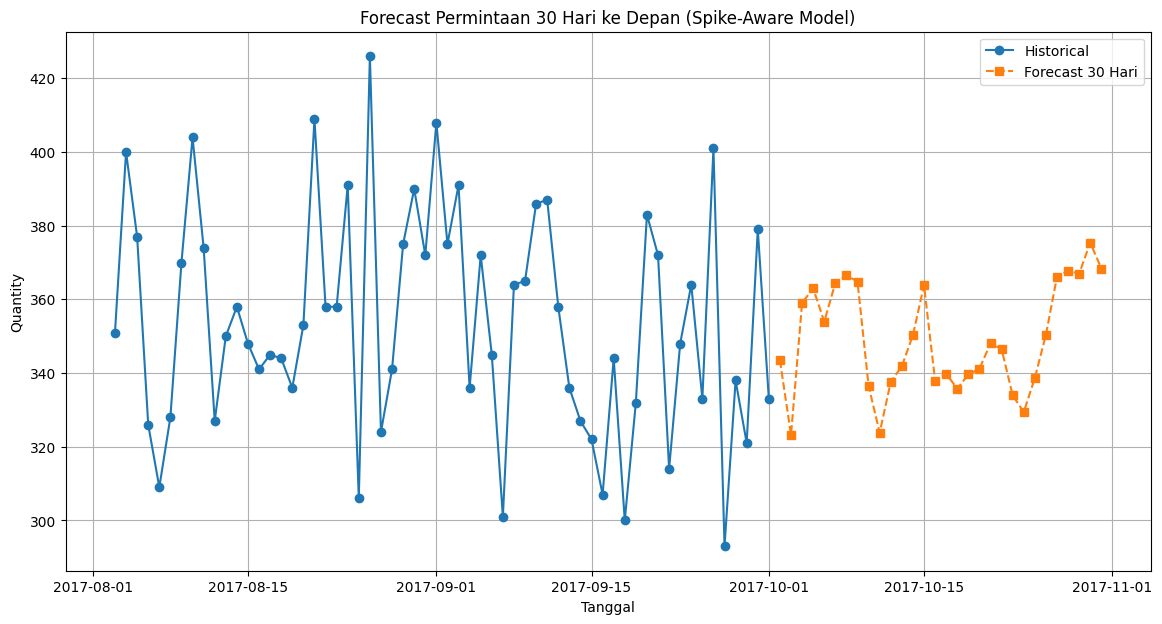

In [154]:
# --- VISUALISASI HASIL PREDIKSI ---
plt.figure(figsize=(14,7))

plt.plot(df_model['ds'].tail(60),
         df_model['y'].tail(60),
         label='Historical',
         marker='o')

plt.plot(forecast_df['Tanggal'],
         forecast_df['Forecast'],
         label='Forecast 30 Hari',
         linestyle='--',
         marker='s')

plt.title('Forecast Permintaan 30 Hari ke Depan (Spike-Aware Model)')
plt.xlabel('Tanggal')
plt.ylabel('Quantity')
plt.legend()
plt.grid(True)

plt.show()